# EfficientNetB0 — Transfer Learning

BATCH=16, warmup 3@1e-3, finetune 5@1e-4 (last 50%), early stopping patience=2, original augmentations.

## Confirm Runtime & GPU

In [3]:
import sys, platform, tensorflow as tf, subprocess, shlex
print("Python:", sys.version)
print("OS:", platform.platform())
print("TF:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))
try:
    print("\nNVIDIA-SMI:")
    subprocess.run(shlex.split("nvidia-smi"), check=False)
except Exception as e:
    print("nvidia-smi not available:", e)

Python: 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]
OS: Linux-6.6.97+-x86_64-with-glibc2.35
TF: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

NVIDIA-SMI:


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## !rsync data copy

In [5]:
from google.colab import drive
drive.mount('/content/drive')
!rsync -ah --info=progress2 "/content/drive/MyDrive/Data/" "/content/Data/"
DATA_DIR = "/content/Data"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
        124.96M 100%  444.38kB/s    0:04:34 (xfr#1000, to-chk=0/1019)


## Imports

In [6]:
import os, json, collections, numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf, keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
SEED = 42
tf.keras.utils.set_random_seed(SEED)
print("TF:", tf.__version__, "| Keras:", keras.__version__)

TF: 2.19.0 | Keras: 3.10.0


## Configuration

In [7]:
DATA_DIR = "/content/Data"
IMG_SIZE = (224, 224)
BATCH = 16
WARMUP_EPOCHS = 3
WARMUP_LR = 1e-3
FT_EPOCHS = 5
FT_LR = 1e-4
OUT_DIR = "outputs_effnetb0_original"
os.makedirs(OUT_DIR, exist_ok=True)

## Dataset Loaders

In [10]:
train_raw = make_ds("train", IMG_SIZE, BATCH, True)
val_raw   = make_ds("valid", IMG_SIZE, BATCH, False)
test_raw  = make_ds("test",  IMG_SIZE, BATCH, False)

CLASS_NAMES = train_raw.class_names
N_CLASSES   = len(CLASS_NAMES)
IMG_SIZE    = (224, 224)
BATCH       = 16
OUT_DIR     = "outputs_effnetb0_original"
os.makedirs(OUT_DIR, exist_ok=True)

# Quick counts
def _counts(ds, n):
    c = [0]*n
    for _, yb in ds.unbatch():
        c[int(yb.numpy())]+=1
    return c

print("Label counts — train:", _counts(train_raw, N_CLASSES))
print("Label counts — valid:", _counts(val_raw,  N_CLASSES))
print("Label counts — test :", _counts(test_raw,  N_CLASSES))

Found 613 files belonging to 4 classes.
Found 72 files belonging to 4 classes.
Found 315 files belonging to 4 classes.
Label counts — train: [195, 115, 148, 155]
Label counts — valid: [23, 21, 13, 15]
Label counts — test : [120, 51, 54, 90]


## Preprocessing & Augmentation (Pipeline/Data)

In [11]:
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.04),
    layers.RandomBrightness(0.10),
    layers.RandomContrast(0.10),
], name="data_aug")

def prep_batch(x, y, training=False):
    x = tf.cast(x, tf.float32)
    if training:
        x = data_aug(x, training=True)
    return x, y

train_ds = train_raw.map(lambda x,y: prep_batch(x,y,training=True),
                         num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
val_ds   = val_raw.map(lambda x,y: prep_batch(x,y,training=False),
                       num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
test_ds  = test_raw.map(lambda x,y: prep_batch(x,y,training=False),
                        num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

## Class Weights

In [12]:
counts = collections.Counter()
for _, yb in train_raw.unbatch():
    counts[int(yb.numpy())] += 1
total = sum(counts.values()) + 1e-8
class_weights = {}
for i in range(N_CLASSES):
    freq = counts.get(i, 0) / total
    class_weights[i] = float(1.0 / (freq + 1e-6))
# normalize weights ~ mean 1.0
mw = sum(class_weights.values())/N_CLASSES
class_weights = {k: v/mw for k,v in class_weights.items()}
print("Class weights:", class_weights)

Class weights: {0: 0.7588292322909316, 1: 1.286707623541546, 2: 0.9998077876816025, 3: 0.9546553564859194}


## Model Preprocessing: Warm-up → Finetune the Last 50%

In [13]:
inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base   = EfficientNetB0(include_top=False, weights="imagenet",
                        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base.trainable = False  # warm-up

x = inputs
x = preprocess_input(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(N_CLASSES, activation="softmax")(x)
model = keras.Model(inputs, outputs, name="efficientnetb0_tl")

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetb0_tl"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Phase 1 — Train Head

In [14]:
# === PHASE 1: head training (base frozen) ===
WARMUP_EPOCHS = 3
WARMUP_LR     = 1e-3

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=WARMUP_LR),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=["accuracy"])

ckpt_warm = os.path.join(OUT_DIR, "warmup_best.keras")
csv_log   = os.path.join(OUT_DIR, "training_log.csv")
callbacks_warm = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(ckpt_warm, monitor="val_loss", save_best_only=True),
    keras.callbacks.CSVLogger(csv_log, append=True),
]
hist_warm = model.fit(train_ds, validation_data=val_ds,
                      epochs=WARMUP_EPOCHS, class_weight=class_weights,
                      callbacks=callbacks_warm, verbose=1)

Epoch 1/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.3552 - loss: 1.2953 - val_accuracy: 0.4722 - val_loss: 1.0434
Epoch 2/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.5810 - loss: 0.8671 - val_accuracy: 0.4722 - val_loss: 0.9520
Epoch 3/3
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6014 - loss: 0.7755 - val_accuracy: 0.5000 - val_loss: 0.8863


## Phase 2 — FT the Last 50%

In [15]:
FT_EPOCHS = 5
FT_LR     = 1e-4

n = len(base.layers)
for i, layer in enumerate(base.layers):
    layer.trainable = (i >= n//2)   # unfreeze last half

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=FT_LR),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=["accuracy"])

ckpt_ft = os.path.join(OUT_DIR, "finetune_best.keras")
callbacks_ft = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(ckpt_ft, monitor="val_loss", save_best_only=True),
    keras.callbacks.CSVLogger(csv_log, append=True),
]
hist_ft = model.fit(train_ds, validation_data=val_ds,
                    epochs=FT_EPOCHS, class_weight=class_weights,
                    callbacks=callbacks_ft, verbose=1)

Epoch 1/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.5652 - loss: 0.9939 - val_accuracy: 0.4583 - val_loss: 0.9301
Epoch 2/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.7415 - loss: 0.6782 - val_accuracy: 0.5694 - val_loss: 0.8697
Epoch 3/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.8575 - loss: 0.4488 - val_accuracy: 0.6250 - val_loss: 0.7659
Epoch 4/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.8972 - loss: 0.3293 - val_accuracy: 0.7361 - val_loss: 0.6381
Epoch 5/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9318 - loss: 0.2517 - val_accuracy: 0.8333 - val_loss: 0.4493


## Save Model & Metadata

In [16]:
final_model_path = os.path.join(OUT_DIR, "efficientnetb0_ct_final.keras")
keras.saving.save_model(model, final_model_path)
print("Saved:", final_model_path)

meta = {"class_names": CLASS_NAMES, "image_size": list(IMG_SIZE),
        "architecture": "EfficientNetB0 transfer (original schedule, dotted class names)"}
with open(os.path.join(OUT_DIR, "model_meta.json"), "w") as f:
    json.dump(meta, f, indent=2)
print("Saved:", os.path.join(OUT_DIR, "model_meta.json"))

Saved: outputs_effnetb0_original/efficientnetb0_ct_final.keras
Saved: outputs_effnetb0_original/model_meta.json


## Evaluation (Acc, macro-F1, macro-AUC, Confusion Matrix)

VAL  — Acc: 0.8333 | F1_macro: 0.8459 | AUC_macro: 0.9683
[[20  0  0  3]
 [ 5 14  0  2]
 [ 1  0 12  0]
 [ 1  0  0 14]]
TEST — Acc: 0.8571 | F1_macro: 0.8551 | AUC_macro: 0.9691
[[111   1   0   8]
 [ 17  30   0   4]
 [  1   0  53   0]
 [ 14   0   0  76]]
Saved results table -> outputs_effnetb0_original/results_table.csv


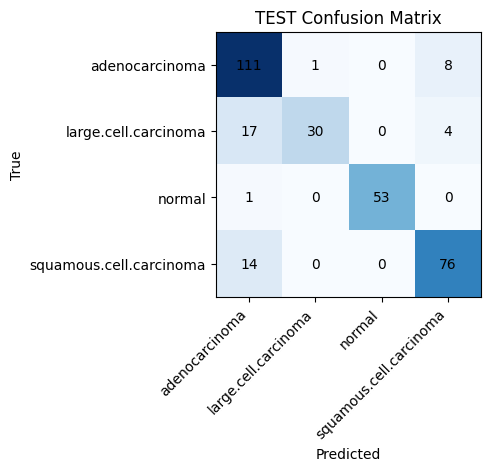

In [48]:
def eval_split(ds, split_name):
    y_true, y_prob = [], []
    for xb, yb in ds:
        p = model(xb, training=False).numpy()
        y_prob.append(p); y_true.extend(yb.numpy().tolist())
    y_prob = np.concatenate(y_prob, axis=0)
    y_true = np.array(y_true)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    rep = classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                                output_dict=True, zero_division=0)
    macro_f1 = rep["macro avg"]["f1-score"]

    y_true_oh = label_binarize(y_true, classes=list(range(N_CLASSES)))
    try:
        macro_auc = roc_auc_score(y_true_oh, y_prob, average="macro", multi_class="ovr")
    except Exception:
        macro_auc = float("nan")

    cm = confusion_matrix(y_true, y_pred)
    print(f"{split_name} — Acc: {acc:.4f} | F1_macro: {macro_f1:.4f} | AUC_macro: {macro_auc:.4f}")
    print(cm)
    return acc, macro_f1, macro_auc, cm

acc_v, f1_v, auc_v, cm_v = eval_split(val_ds,  "VAL ")
acc_t, f1_t, auc_t, cm_t = eval_split(test_ds, "TEST")

# save results table for Hugging Face app
results = pd.DataFrame([{"model":"EfficientNetB0_TL_ORIG",
                         "accuracy":acc_t, "macro_f1":f1_t, "macro_auc":auc_t}])
results_path = os.path.join(OUT_DIR, "results_table.csv")
results.to_csv(results_path, index=False)
print("Saved results table ->", results_path)

# quick CM plot (optional)
fig, ax = plt.subplots(figsize=(5,5))
im = ax.imshow(cm_t, cmap="Blues")
ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right"); ax.set_yticklabels(CLASS_NAMES)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, cm_t[i, j], ha="center", va="center", color="black")
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("TEST Confusion Matrix")
plt.tight_layout(); plt.show()

## Grad-CAM Visualization

In [99]:
# --- Robust Grad-CAM for your EfficientNet wrapper (Keras 3 safe) ---
import tensorflow as tf, numpy as np, matplotlib.pyplot as plt, matplotlib.cm as cm
import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.efficientnet import preprocess_input

def make_efficientnet_gradcam_model(model,
                                    base_name="efficientnetb0",
                                    conv_name="top_conv"):
    """
    Build a tiny graph that shares your EfficientNet base + Dense head weights.
    Input: raw RGB (H,W,3)  ->  Outputs: (conv feature map at `conv_name`, softmax probs)
    """
    # 1) nested EfficientNet submodel + your final Dense head
    base_sub    = model.get_layer(base_name)   # Functional submodel
    final_dense = model.layers[-1]             # Dense(..., softmax) from your wrapper

    # 2) new input for this grad-cam graph
    inp = keras.Input(shape=model.input_shape[1:])  # (H,W,3) RGB

    # 3) SAME preprocessing as main model, but WRAPPED as a Keras layer
    x = layers.Lambda(preprocess_input, name="gc_preprocess")(inp)

    # 4) forward through EfficientNet base to feature maps
    fm = base_sub(x, training=False)

    # 5) IMPORTANT: use an intermediate model for conv features, called on *x*
    conv_extractor = keras.Model(base_sub.input, base_sub.get_layer(conv_name).output, name="gc_conv_extractor")
    conv_out = conv_extractor(x, training=False)   # (h,w,c) on the SAME graph

    # 6) re-create your head with the SAME trained weights using Keras ops
    gap    = layers.GlobalAveragePooling2D(name="gc_gap")(fm)
    W, b   = final_dense.get_weights()            # (feat_dim, n_classes), (n_classes,)
    logits = layers.Lambda(lambda t: tf.linalg.matmul(t, W) + b, name="gc_logits")(gap)
    probs  = layers.Activation("softmax", name="gc_softmax")(logits)

    return keras.Model(inp, [conv_out, probs], name="gradcam_efficientnet")

def grad_cam_efficientnet(model, img_tensor,
                          base_name="efficientnetb0",
                          conv_name="top_conv",
                          class_index=None):
    """
    img_tensor must be RAW RGB of shape (1,H,W,3). Do NOT preprocess beforehand.
    Returns a (H,W) heatmap in [0,1].
    """
    gc = make_efficientnet_gradcam_model(model, base_name, conv_name)

    with tf.GradientTape() as tape:
        conv_out, probs = gc(img_tensor, training=False)
        if class_index is None:
            class_index = tf.argmax(probs[0])
        loss = probs[:, class_index]

    grads   = tape.gradient(loss, conv_out)                      # (1,h,w,c)
    weights = tf.reduce_mean(grads, axis=(1, 2), keepdims=True)  # (1,1,1,c)
    cam     = tf.reduce_sum(weights * conv_out, axis=-1)[0]      # (h,w)

    cam = tf.maximum(cam, 0) / (tf.reduce_max(cam) + 1e-8)
    cam = tf.image.resize(cam[..., None], img_tensor.shape[1:3]).numpy().squeeze()
    return cam

def show_gradcam_example(ds, layer_name="top_conv", alpha=0.35, base_name="efficientnetb0"):
    for xb, yb in ds.take(1):
        img = xb[0:1]  # RAW (1,H,W,3)
        heat = grad_cam_efficientnet(model, img, base_name=base_name, conv_name=layer_name)

        probs = model(img, training=False).numpy()[0]
        pred_idx = int(np.argmax(probs)); true_idx = int(yb.numpy()[0])

        img_uint8 = np.clip(img[0].numpy(), 0, 255).astype("uint8")
        heat_rgb  = (cm.jet(heat)[..., :3] * 255).astype(np.uint8)
        overlay   = (alpha * heat_rgb + (1 - alpha) * img_uint8).astype(np.uint8)

        fig, axs = plt.subplots(1, 3, figsize=(12, 4))
        axs[0].imshow(img_uint8); axs[0].set_title("Input"); axs[0].axis("off")
        axs[1].imshow(heat, cmap="jet"); axs[1].set_title("Grad-CAM"); axs[1].axis("off")
        axs[2].imshow(overlay); axs[2].set_title(f"Overlay (alpha={alpha})"); axs[2].axis("off")
        fig.suptitle(f"true: {CLASS_NAMES[true_idx]} | pred: {CLASS_NAMES[pred_idx]}", y=1.02)
        plt.tight_layout(); plt.show()
        break

## Grad-CAM Visualizations

In [100]:
def show_gradcam_example(ds, layer_name="top_conv", alpha=0.35, base_name="efficientnetb0"):
    for xb, yb in ds.take(1):
        img = xb[0:1]  # RAW (1,H,W,3)
        heat = grad_cam_efficientnet(model, img, base_name=base_name, conv_name=layer_name)

        probs = model(img, training=False).numpy()[0]
        pred_idx = int(np.argmax(probs)); true_idx = int(yb.numpy()[0])

        img_uint8 = np.clip(img[0].numpy(), 0, 255).astype("uint8")
        heat_rgb  = (cm.jet(heat)[..., :3] * 255).astype(np.uint8)
        overlay   = (alpha * heat_rgb + (1 - alpha) * img_uint8).astype(np.uint8)

        fig, axs = plt.subplots(1, 3, figsize=(12, 4))
        axs[0].imshow(img_uint8); axs[0].set_title("Input"); axs[0].axis("off")
        axs[1].imshow(heat, cmap="jet"); axs[1].set_title("Grad-CAM"); axs[1].axis("off")
        axs[2].imshow(overlay); axs[2].set_title(f"Overlay (alpha={alpha})"); axs[2].axis("off")
        fig.suptitle(f"true: {CLASS_NAMES[true_idx]} | pred: {CLASS_NAMES[pred_idx]}", y=1.02)
        plt.tight_layout(); plt.show()
        break

In [111]:
# Import necessary packages and libraries
import torchvision
import torch
import numpy as np
import torch.nn as nn
from PIL import Image
import torchvision.transforms as transforms
import cv2
import matplotlib.pyplot as plt


# Load pre-trained model
vgg_model = torchvision.models.vgg16(pretrained=True)

# transformation for passing image into the network
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# selecting layers from the model to generate activations
image_to_heatmaps = nn.Sequential(*list(vgg_model.features[:-4]))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 91.8MB/s]


In [112]:
def compute_heatmap(model,img):
  model.eval()
  # compute logits from the model
  logits = model(img)
  # model's prediction
  pred = logits.max(-1)[-1]
  # activations from the model
  activations = image_to_heatmaps(img)
  # compute gradients with respect to the model's most confident prediction
  logits[0, pred].backward(retain_graph=True)
  # average gradients of the featuremap
  pool_grads = model.features[-3].weight.grad.data.mean((0,2,3))
  # multiply each activation map with corresponding gradient average
  for i in range(activations.shape[1]):
    activations[:,i,:,:] *= pool_grads[i]
  # calculate mean of weighted activations
  heatmap = torch.mean(activations, dim=1)[0].cpu().detach()
  return heatmap, pred

In [113]:
def upsampleHeatmap(map, image):
  # permute image
  image = image.squeeze(0).permute(1, 2, 0).cpu().numpy()
  # maximum and minimum value from heatmap
  m, M = map.min(), map.max()
  # normalize the heatmap
  map = 255 * ((map-m)/ (m-M))
  map = np.uint8(map)
  # resize the heatmap to the same as the input
  map = cv2.resize(map, (224, 224))
  map = cv2.applyColorMap(255-map, cv2.COLORMAP_JET)
  map = np.uint8(map)
  # change this to balance between heatmap and image
  map = np.uint8(map*0.7 + image*0.3)
  return map

In [118]:
def display_images(upsampled_map, image_tensor):
    # Prepare the original image tensor for display
    # Remove batch dimension, permute channels from (C, H, W) to (H, W, C)
    image_display = image_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()

    # Denormalize the image for display (assuming standard ImageNet normalization)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image_display = std * image_display + mean
    image_display = np.clip(image_display, 0, 1) # Clip values to the valid range [0, 1]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # upsampled_map is already in uint8 [0, 255] range
    axes[0].imshow(upsampled_map)
    axes[0].set_title("Heatmap")
    axes[0].axis('off')

    # Display the denormalized original image
    axes[1].imshow(image_display)
    axes[1].set_title("Original Image")
    axes[1].axis('off')

    plt.show()

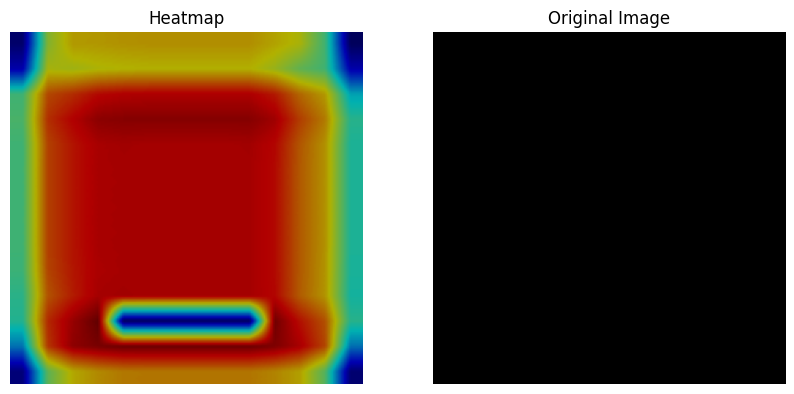

In [119]:
# Upsample the heatmap
upsampled_map = upsampleHeatmap(heatmap, img_tensor)

# Display the heatmap and the original image
display_images(upsampled_map, img_tensor)

In [116]:
# Load an example image (replace with your image path)
# For demonstration, let's create a dummy image
# In a real scenario, you would load an image file
from PIL import Image
import numpy as np

# Create a dummy image (e.g., a black image)
img_np = np.zeros((224, 224, 3), dtype=np.uint8)
img = Image.fromarray(img_np)

# Apply the transformation defined earlier for the VGG model
img_tensor = transform(img).unsqueeze(0) # Add batch dimension

# Call compute_heatmap with the image tensor and the VGG model
heatmap, pred = compute_heatmap(vgg_model, img_tensor)

# Now you can print the prediction
print(f"Prediction: {pred}")

Prediction: tensor([644])


## Final Save Model

In [121]:
import tensorflow as tf, numpy as np, matplotlib.pyplot as plt, matplotlib.cm as cm
import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.efficientnet import preprocess_input

# Removed make_efficientnet_gradcam_model as we build the partial model directly

def grad_cam_efficientnet(model, img_tensor,
                          base_name="efficientnetb0",
                          conv_name=None, # conv_name will be found automatically if None
                          class_index=None):
    """
    img_tensor must be RAW RGB (1,H,W,3) — do NOT preprocess before calling.
    Returns heatmap (H,W) in [0,1].
    """
    # auto-detect layer name if not provided
    if conv_name is None:
        conv_name = _find_last_conv_name(model)
    if not conv_name:
        raise ValueError("Could not find a suitable convolutional layer for Grad-CAM.")

    # Find the convolutional layer object
    conv_layer = None
    for layer in model.layers:
        if layer.name == conv_name:
            conv_layer = layer
            break
        # Check within nested functional models like the EfficientNet base
        if isinstance(layer, keras.Model):
             for sub_layer in layer.layers:
                 if sub_layer.name == conv_name:
                     conv_layer = sub_layer
                     break
        if conv_layer:
            break

    if not conv_layer:
         raise ValueError(f"Could not find layer object with name '{conv_name}' in the model.")

    # Build a partial model by tracing the graph
    input_tensor = model.inputs[0]
    # Get the tensor output of the convolutional layer
    conv_output_tensor = conv_layer.output
    # Get the final output tensor of the model
    final_output_tensor = model.output

    grad_model = keras.models.Model(
        inputs=input_tensor,
        outputs=[conv_output_tensor, final_output_tensor]
    )


    with tf.GradientTape() as tape:
        # Preprocess the image inside the tape for correct gradients
        img_processed = preprocess_input(img_tensor)
        conv_out, probs = grad_model(img_processed, training=False)
        if class_index is None:
            class_index = tf.argmax(probs[0])
        loss = probs[:, class_index]

    grads   = tape.gradient(loss, conv_out)                 # (1,h,w,c)
    weights = tf.reduce_mean(grads, axis=(1, 2), keepdims=True)  # (1,1,1,c)
    cam     = tf.reduce_sum(weights * conv_out, axis=-1)[0]      # (h,w)

    cam = tf.maximum(cam, 0) / (tf.reduce_max(cam) + 1e-8)
    # Add batch and channel dimensions before resizing
    cam = cam[tf.newaxis, ..., tf.newaxis]
    cam = tf.image.resize(cam, img_tensor.shape[1:3]).numpy().squeeze()
    return cam

In [122]:
final_model_path = os.path.join(OUT_DIR, "efficientnetb0_ct_final.keras")
keras.saving.save_model(model, final_model_path)
print("Saved model ->", final_model_path)

meta = {"class_names": CLASS_NAMES,
        "image_size": list(IMG_SIZE),
        "architecture": "EfficientNetB0 transfer (warmup 3@1e-3; FT last-50% 5@1e-4)"}
with open(os.path.join(OUT_DIR, "model_meta.json"), "w") as f:
    json.dump(meta, f, indent=2)
print("Saved meta ->", os.path.join(OUT_DIR, "model_meta.json"))

Saved model -> outputs_effnetb0_original/efficientnetb0_ct_final.keras
Saved meta -> outputs_effnetb0_original/model_meta.json
